# 024 — Training: beta sweep on `unet_nll` (Laplace NLL)

Sweeps the **beta exponent** of the Laplace NLL (`scripts.losses.laplace_nll_loss`)
on a single architecture, `unet_nll`, holding everything else at the Round 1/2
recipe used by `021_training_nll.ipynb`. Same dataset, same split, same seed, same
optimizer — **only `beta` moves**.

**What beta does.** The loss is `stop_gradient(b)^beta * (|y - mu| / b + log b)`.
Because the weight is detached and strictly positive, beta does **not** move the
optimum for `b` (still `b* = |y - mu|`); it rescales each pixel's contribution. On
the gradient reaching `mu` it acts as `1 / b^(1 - beta)`: `beta = 0` gives the plain
Laplace NLL (`1 / b`, high-uncertainty regions downweighted most), `beta = 1` removes
the weighting entirely. This is the Seitzer et al. (2022) reweighting, adapted from
the Gaussian variance to the Laplace scale (`scripts/losses.py`, `fixing.md` #10).

**Why this sweep, and why on this architecture.** `C1_v1_v2_beta.ipynb` established
that at matched `beta = 0.5` the Laplace NLL is far better calibrated than the
Gaussian one (`z_std` 0.74-0.91 vs. 0.30-0.41; `error_sigma_spearman` positive vs.
negative in 3 of 4 architectures), settling the *distribution* question. It left the
*beta* question open: `C0`+`C1` together show that on the **Gaussian**, moving
`beta` from 0 to 0.5 is catastrophic for calibration (4/4 architectures), but the
Laplace at `beta = 0.5` shows none of that damage — so the Gaussian evidence does not
transfer, and the shape of the Laplace beta curve is unmeasured. `unet_nll` is the
pilot because beta acts on the sigma head and it has the healthiest one in the
current generation (`z_std` 0.9090, the closest to 1.0 of the four; `coverage_2s`
0.9525 against a nominal 0.9545), plus the best fidelity of any v2 model
(mae 0.1012, psnr 18.16) — so a beta effect is measured from a clean baseline rather
than on top of a broken one.

**Grid**: `beta` in `{0.0, 0.25, 0.75}`. `beta = 0.5` is **not** retrained — the
existing `models/nll/unet_nll/` checkpoint is that point of the curve, and §5 reads
its `history.json` alongside the new runs. The grid deliberately brackets it on both
sides: sampling only below 0.5 could not detect an optimum above it. `beta = 1.0` is
left out as the degenerate end (no weighting on `mu` at all).

Companion notebooks: `021_training_nll.ipynb` (the `beta = 0.5` run this extends),
`C1_v1_v2_beta.ipynb` (the comparison that motivated it). See `020_training.ipynb`'s
title cell for the full table.

Only the **artwork-and-mockups** split is used (see §1).


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.


In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports, a fixed global seed, and a GPU sanity check.


In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.visualization import plot_training_curves

set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Dataset — artwork-and-mockups split

Same split as `020`/`021`/`022`/`023` §1 — required so these checkpoints are trained and evaluated under the same conditions as the `beta = 0.5` run they are compared against.


In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


2026-08-27 09:50:34.897257: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-27 09:50:34.897280: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-27 09:50:34.897284: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-27 09:50:34.897301: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 09:50:34.897311: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Loss function — Laplace NLL at several betas

Every run uses `loss_name="laplace_nll"`; only `beta` differs. `compile_model_nll`
takes it as a parameter (`scripts/trainer_nll.py`), and `scripts/train_single.py`
now exposes it as `--nll-beta` — passing it on the command line rather than through
ambient config means each run's beta is recorded in the command that launched it,
which matters here because the value does not survive into the checkpoint.

`min_log_var`/`max_log_var` stay at `settings.NLL_LOG_VAR_MIN`/`_MAX`; on this loss
they clip the **log-scale** channel, not a log-variance (`fixing.md` #10 — the field
kept its original name).


## 3. Train one run per beta

Each beta trains in its own **subprocess** (`scripts/train_single.py --nll
--nll-beta`), same reasoning as `020_training.ipynb` §3 (`fixing.md` §7: training
several Keras models back-to-back in one process leaves GPU-side state behind that
`clear_session()` does not fully release on this hardware).

Checkpoints go to `models/beta_sweep/beta_<value>/unet_nll/best_model.keras` — one
directory per beta, with the architecture name kept intact inside it so
`load_model_nll(arch, model_dir=...)` resolves them later without special-casing.
Each subprocess also writes `history.json` next to its checkpoint.

`set_global_seed()` runs inside every subprocess, so the runs differ by beta and by
nothing else the pipeline controls. Set `EPOCHS = 2` for a quick smoke test before
committing to a full sweep.


In [4]:
import json
import subprocess

ARCH = "unet_nll"
LOSS_NAME = "laplace_nll"
BETAS = [0.0, 0.25, 0.75]  # 0.5 already trained -> models/nll/unet_nll/
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
SWEEP_DIR = settings.MODELS_DIR / "beta_sweep"
SWEEP_LOG_DIR = settings.LOGS_DIR / "beta_sweep"

# The beta=0.5 reference, trained by 021 — read, never retrained.
REFERENCE_BETA = settings.NLL_BETA
REFERENCE_DIR = settings.MODELS_DIR / "nll"


def run_dir(root: Path, beta: float) -> Path:
    """``<root>/beta_<value>`` — one directory per sweep point."""
    return root / f"beta_{beta:.2f}"


histories: dict[float, dict] = {}

for beta in BETAS:
    model_dir = run_dir(SWEEP_DIR, beta)
    cmd = [
        sys.executable,
        "-m",
        "scripts.train_single",
        "--arch",
        ARCH,
        "--epochs",
        str(EPOCHS),
        "--model-dir",
        str(model_dir),
        "--log-dir",
        str(run_dir(SWEEP_LOG_DIR, beta)),
        "--nll",
        "--loss-name",
        LOSS_NAME,
        "--nll-beta",
        str(beta),
    ]
    subprocess.run(cmd, cwd=project_root, check=True)

    history_path = model_dir / ARCH / "history.json"
    histories[beta] = json.loads(history_path.read_text())

    best_val_loss = min(histories[beta]["val_loss"])
    print(f"\nBest val_loss ({ARCH}, beta={beta}): {best_val_loss:.4f}")


2026-08-27 09:50:37.241048: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-27 09:50:37.241067: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-27 09:50:37.241073: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-27 09:50:37.241084: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 09:50:37.241093: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: unet_nll (laplace_nll, beta=0.0)
Model: "unet_nll"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-27 09:50:39.238025: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: -0.7096 - mae: 0.1782 - psnr: 15.2288 - ssim: 0.3240
Epoch 1: val_loss improved from None to -0.91688, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.00/unet_nll/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.00/unet_nll/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - loss: -0.7096 - mae: 0.1782 - psnr: 15.2288 - ssim: 0.3240 - val_loss: -0.9169 - val_mae: 0.1458 - val_psnr: 16.8259 - val_ssim: 0.4863 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - loss: -0.9830 - mae: 0.1383 - psnr: 17.4793 - ssim: 0.4415
Epoch 2: val_loss improved from -0.91688 to -1.03505, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.00/unet_nll/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta

2026-08-27 10:40:21.444243: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-27 10:40:21.444262: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-27 10:40:21.444267: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-27 10:40:21.444282: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 10:40:21.444291: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


...

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: -0.4571 - mae: 0.1787 - psnr: 15.2268 - ssim: 0.3186
Epoch 1: val_loss improved from None to -0.55735, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.25/unet_nll/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.25/unet_nll/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - loss: -0.4571 - mae: 0.1787 - psnr: 15.2268 - ssim: 0.3186 - val_loss: -0.5573 - val_mae: 0.1467 - val_psnr: 16.7565 - val_ssim: 0.4497 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: -0.5931 - mae: 0.1399 - psnr: 17.3890 - ssim: 0.4393
Epoch 2: val_loss improved from -0.55735 to -0.62735, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.25/unet_nll/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sw

2026-08-27 11:30:05.135065: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-27 11:30:05.135084: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-27 11:30:05.135089: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-27 11:30:05.135101: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 11:30:05.135111: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: unet_nll (laplace_nll, beta=0.75)
Model: "unet_nll"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼──────────────

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-27 11:30:07.209935: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: -0.1849 - mae: 0.1852 - psnr: 14.9805 - ssim: 0.3115
Epoch 1: val_loss improved from None to -0.20844, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.75/unet_nll/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.75/unet_nll/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - loss: -0.1849 - mae: 0.1852 - psnr: 14.9805 - ssim: 0.3115 - val_loss: -0.2084 - val_mae: 0.1544 - val_psnr: 16.3483 - val_ssim: 0.4510 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: -0.2204 - mae: 0.1439 - psnr: 17.2012 - ssim: 0.4188
Epoch 2: val_loss improved from -0.20844 to -0.23554, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.75/unet_nll/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sw

## 4. Pull in the existing `beta = 0.5` run

`021_training_nll.ipynb` already trained this architecture at
`beta = settings.NLL_BETA`; its `history.json` is read here so the curve has four
points instead of three. If that file is missing the sweep still works — the
reference point is simply absent from §5 and §6.

**One caveat on comparing `val_loss` across betas**: the beta weighting multiplies
the loss itself, so a lower `val_loss` at a different beta does *not* mean a better
model — the two numbers are on different scales. Use it to confirm each run
converged, and rank the runs on `030`/`C0`-style metrics (fidelity, and the §8
calibration block: `z_std`, `ence`, `error_sigma_spearman`, coverage) instead. The
`mae` metric (`MuMAEMetric`, the `mu` channel only), which does not carry
the beta weight, is the one training-time number
that *is* comparable across betas.


In [5]:
reference_history_path = REFERENCE_DIR / ARCH / "history.json"

if reference_history_path.exists():
    histories[REFERENCE_BETA] = json.loads(reference_history_path.read_text())
    print(f"Reference run loaded: beta={REFERENCE_BETA} <- {reference_history_path}")
else:
    print(
        f"No reference run at {reference_history_path} — "
        f"sweep has {len(BETAS)} points"
    )

sweep_betas = sorted(histories)
print(f"Betas available: {sweep_betas}")


Reference run loaded: beta=0.5 <- /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/unet_nll/history.json
Betas available: [0.0, 0.25, 0.5, 0.75]


## 5. Training curves

One figure per beta, in ascending order. What to look for: a run that diverges or
plateaus early is a training failure, not a beta result — rerun it before reading
anything into its metrics.


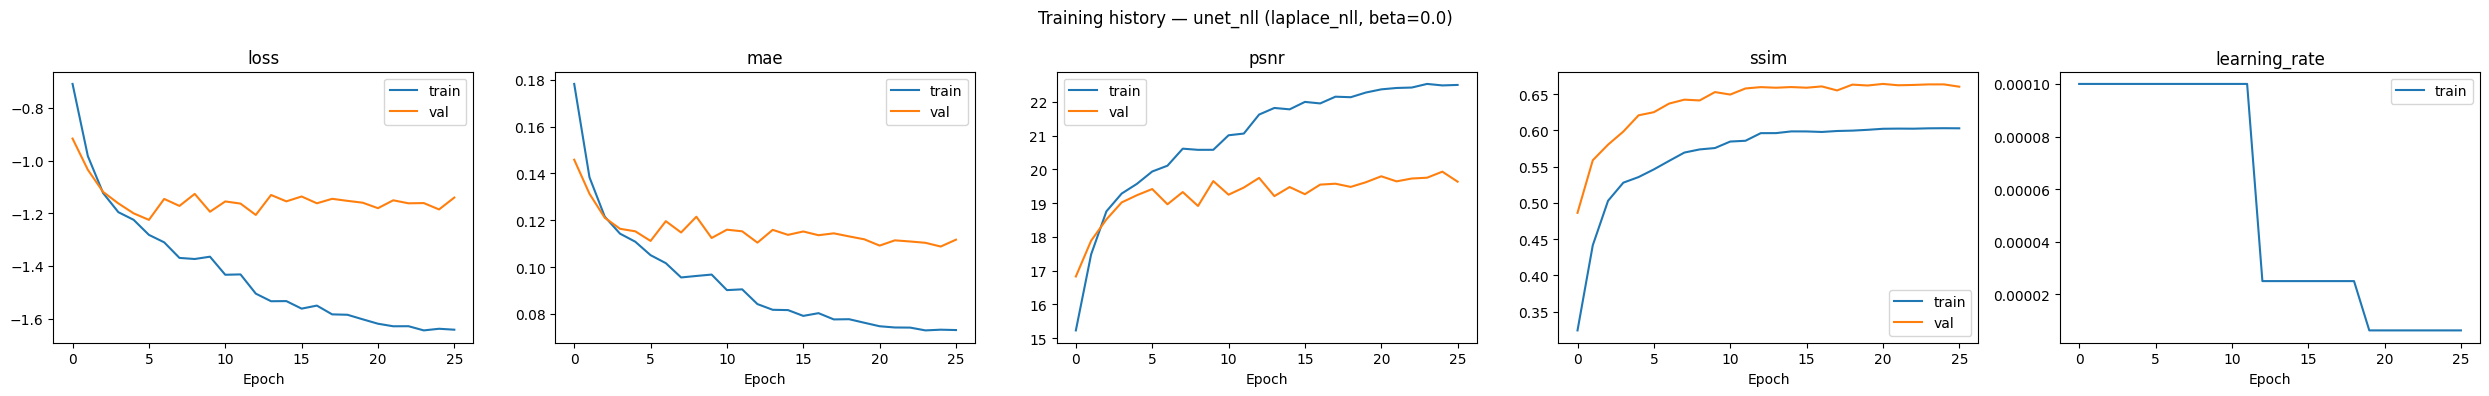

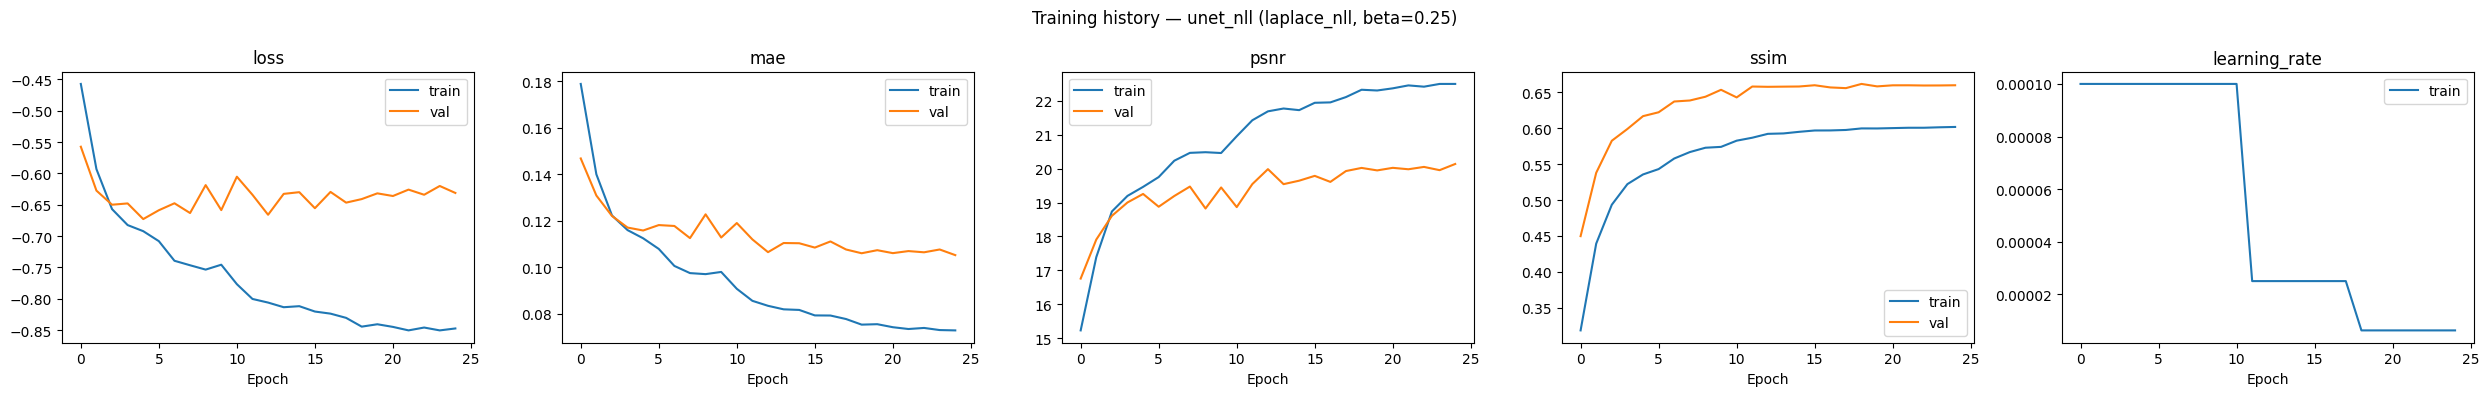

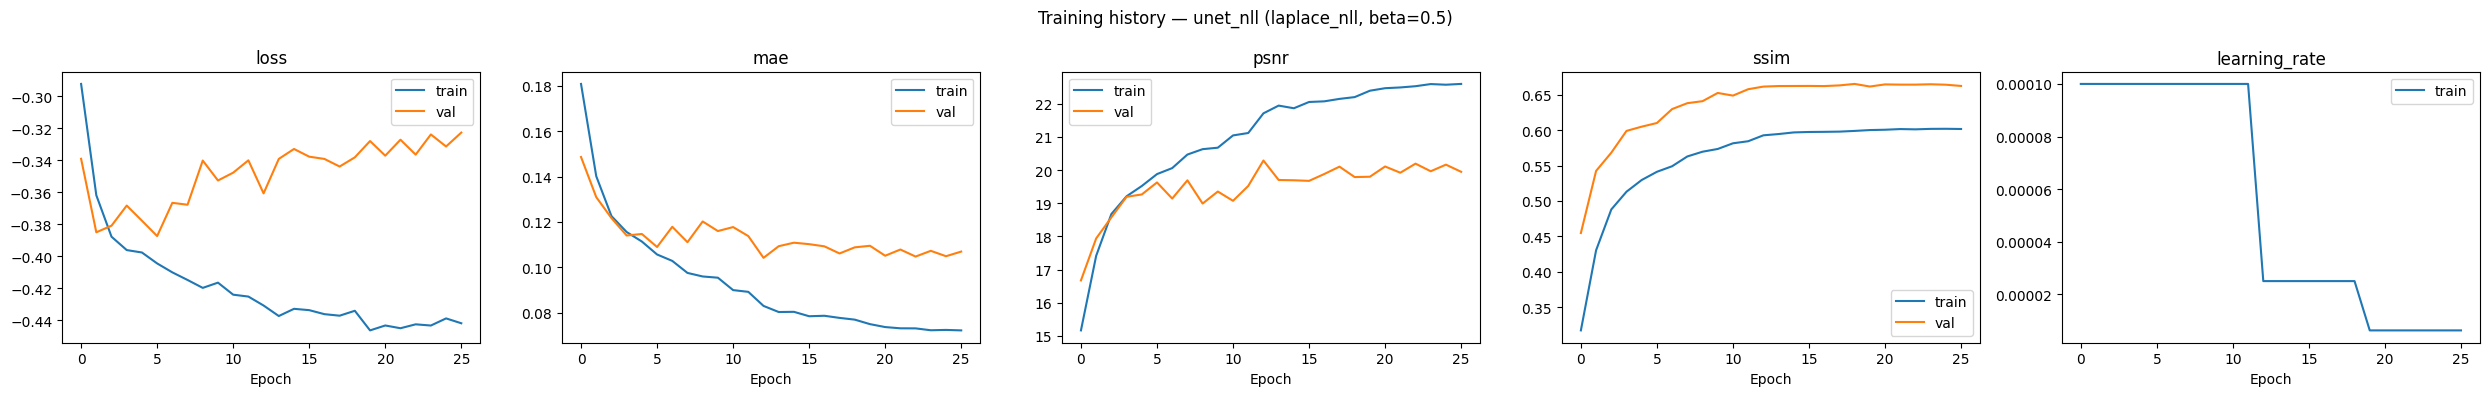

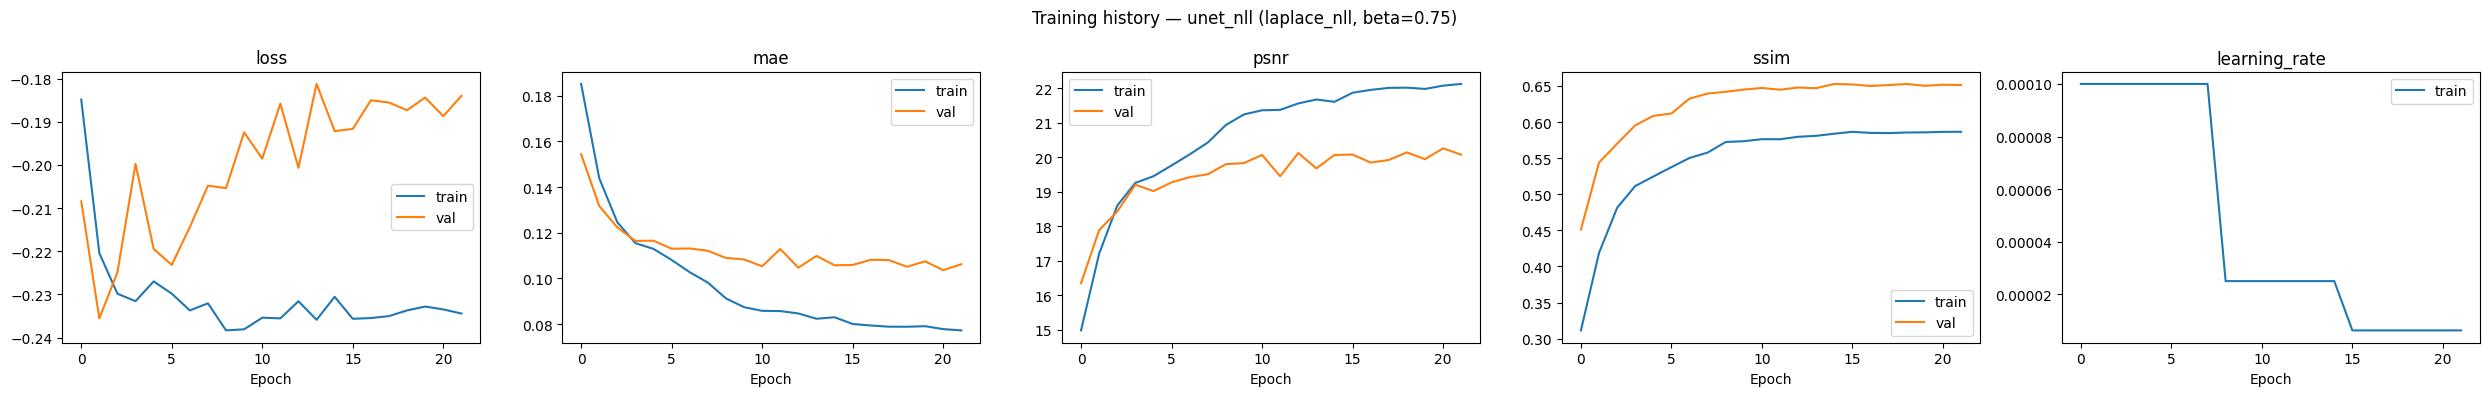

In [6]:
for beta in sweep_betas:
    plot_training_curves(
        histories[beta], title=f"Training history — {ARCH} ({LOSS_NAME}, beta={beta})"
    )
    plt.show()


## 6. Summary

Checkpoints and where they landed. `mae` (`MuMAEMetric`, the `mu` channel only) is reported because, unlike `val_loss`,
it is not multiplied by the beta weight and so is comparable across the sweep — a
first, fidelity-only read on which beta trained best.

**This notebook does not decide anything.** The sigma behaviour is the point of the
sweep, and no training-time metric measures it: score these checkpoints on the §8
calibration block (`z_std` toward 1.0, `ence` down, `error_sigma_spearman` up,
coverage near nominal) before drawing a conclusion. Judge on those and on fidelity —
both computed over all ten `data/test/` images — rather than on detection AUROC,
which rests on three masks and, across `C0`+`C1`, correlates with *worse*
reconstruction (Spearman `rho = +0.665`, `p = 0.005` over the 16 architecture x
generation points) — a confound that has to be ruled out before the AUROC ranking
can be trusted.


In [7]:
for beta in sweep_betas:
    root = REFERENCE_DIR if beta == REFERENCE_BETA else run_dir(SWEEP_DIR, beta)
    ckpt = root / ARCH / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    mae_hist = histories[beta].get("val_mae")
    best_mae = f"{min(mae_hist):.4f}" if mae_hist else "n/a"
    tag = " (reference, from 021)" if beta == REFERENCE_BETA else ""
    print(f"beta={beta:<5} {status:<8} val_mae={best_mae:<8} {ckpt}{tag}")


beta=0.0   found    val_mae=0.1088   /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.00/unet_nll/best_model.keras
beta=0.25  found    val_mae=0.1051   /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.25/unet_nll/best_model.keras
beta=0.5   found    val_mae=0.1041   /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/unet_nll/best_model.keras (reference, from 021)
beta=0.75  found    val_mae=0.1036   /Users/simonecaglio/Documents/GitHub/deep_layers/models/beta_sweep/beta_0.75/unet_nll/best_model.keras
